In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

In [2]:
# load the dataset
curr_path    = os.getcwd()
train_path = os.path.join(os.path.split(curr_path)[0],"data", "train_listings.csv") 
test_path = os.path.join(os.path.split(curr_path)[0],"data", "test_listings.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Get to know the dataset

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5056 entries, 0 to 5055
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5056 non-null   int64  
 1   listing_url                                   5056 non-null   object 
 2   scrape_id                                     5056 non-null   int64  
 3   last_scraped                                  5056 non-null   object 
 4   source                                        5056 non-null   object 
 5   name                                          5056 non-null   object 
 6   description                                   4890 non-null   object 
 7   neighborhood_overview                         2506 non-null   object 
 8   picture_url                                   5056 non-null   object 
 9   host_id                                       5056 non-null   i

In [4]:
train_df["name"][2050]

'Hier wil je verblijven!'

We want to use only the descriptions of the houses in order to asses their price. 
By the description we mean the infromation from:
- "name"
- "description"
- "neighborhood_overview"
- "room_type"
- "amenities"

In addition we will also add the information about the:
- "accommodates" (number of people that can stay in the house)
- "bedrooms" (number of bedrooms in the house)
- "beds" (number of beds in the house)
- "bathrooms" (number of bathrooms in the house)

# Prepocess the data
This includes:
- removing the columns that we do not need
- dealing with prices and outliers
- converting categorical variables to numerical ones
- dealing with amenities
- prepocessing the text data into one description

for more information see the `prepocessing_utils.py` file

In [5]:
from utils.data_prepocessing import full_preprocess
train_df = full_preprocess(train_df)
test_df = full_preprocess(test_df)

d:\uni-Goettingen\SommerSemester 2025\Machine_Learning_Inf\Homeworks\MachineLearningExercises\Project\Description_model\utils\data_prepocessing.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price"].replace({r'\$': '',',':''}, regex=True, inplace=True)
d:\uni-Goettingen\SommerSemester 2025\Machine_Learning_Inf\Homeworks\MachineLearningExercises\Project\Description_model\utils\data_prepocessing.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the doc

# Visualize the data

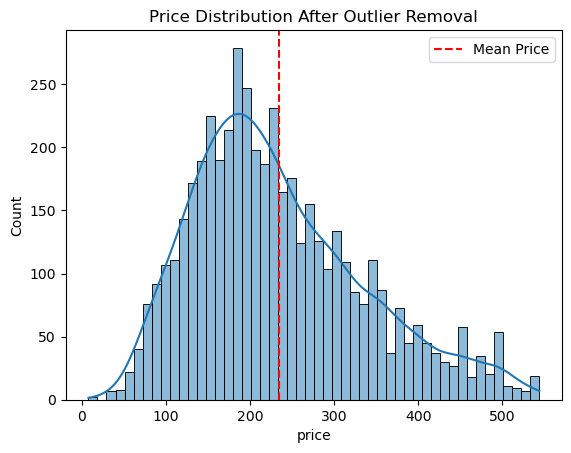

In [6]:
# plot the resulting price distribution after outlier removal
sns.histplot(train_df["price"], bins=50, kde=True)
plt.title("Price Distribution After Outlier Removal")
plt.axvline(train_df["price"].mean(), color='red', linestyle='--', label='Mean Price')
plt.legend()
plt.show()


In [7]:
text_train = " ".join(word for des in train_df.description for word in des)
print("There are {} words in the combination of all descriptions.".format(len(text_train.split())))

text_test = " ".join(word for des in test_df.description for word in des)
print("There are {} words in the combination of all descriptions.".format(len(text_test.split())))


There are 312166 words in the combination of all descriptions.
There are 79588 words in the combination of all descriptions.


(-0.5, 799.5, 399.5, -0.5)

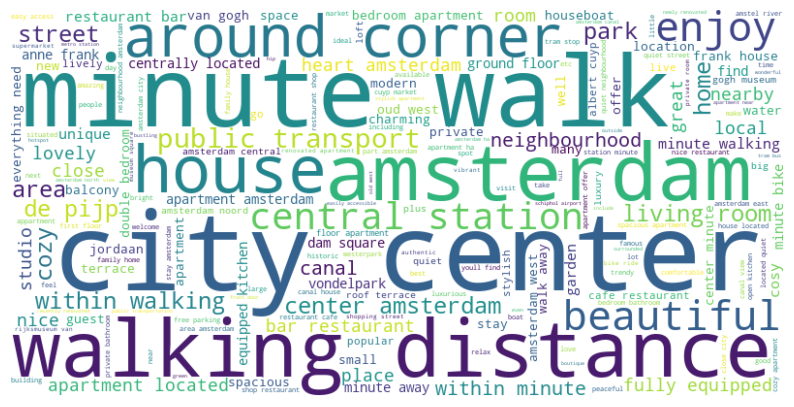

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_train)#max_font_size=100, max_words=500,

# Display the generated image:
# the matplotlib way:
plt.figure(figsize=(10, 20))
plt.subplot(1, 1, 1)
plt.imshow(wordcloud, interpolation='bilinear')
#plt.title("WordCloud for text_train")
plt.axis("off")

# # Generate and plot wordcloud for text_test
# wordcloud_test = WordCloud(width=800, height=400, background_color="white").generate(text_test)
# plt.subplot(2, 1, 2)
# plt.imshow(wordcloud_test, interpolation='bilinear')
# plt.title("WordCloud for text_test")
# plt.axis("off")
# plt.show()
